# Week 04 seminar: Finetuning.

In [1]:
!pip install transformers

In [2]:
import os

import time

import requests

from tqdm.auto import trange, tqdm

from copy import deepcopy

from collections import defaultdict



import numpy as np

import pandas as pd



# charts and display libs

from PIL import Image, ImageFile

import matplotlib.pyplot as plt

%matplotlib inline

from IPython.display import display, HTML



# pytorch

import torch

import torchvision

from torchvision import transforms

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


# Ensure that output below says `device=device(type='cuda')` - you will need CUDA for faster model runs

# If in Colab, we recommend that you go to Runtime -> Change Runtime Type -> GPU



print(f"{torch.__version__=}, {torchvision.__version__=}, {device=}, {torch.get_num_threads()=}")

torch.__version__='2.4.0', torchvision.__version__='0.19.0', device=device(type='cuda', index=0), torch.get_num_threads()=2


## TorchVision



[Torchvision](https://pytorch.org/vision/main/index.html) - part of PyTorch library with convenient tools and data for deep learning in visual domain.

- contains a number of popular vision [datasets](https://pytorch.org/vision/stable/datasets.html)

- preprocessing [tools](https://pytorch.org/vision/stable/transforms.html)

- and most importantly, [pre-trained models](https://pytorch.org/vision/main/models.html).

# Datasets: Imagenet



![imagenet_tiles](https://i.imgur.com/n4QIrzF.jpeg)



Today we're going to use and fine-tune CNN based on weights pre-trained on ImageNet.



What is Imagenet?

- large size image classification dataset.

    - ImageNet-1K contains 1,281,167 training images, 50,000 validation images and 100,000 test images.

    - Full original dataset (ImageNet-21k) contains 14,197,122 images divided into 21,841 classes

    - Resolution varies, average resolution: 469x387 pixels

- built pre-2010 by [Fei-Fei Li](https://en.wikipedia.org/wiki/Fei-Fei_Li) at Princeton

- made very popular by ImageNet Large Scale Visual Recognition Challenge (ILSVRC). See AlexNet moment: [chart](https://www.researchgate.net/figure/ImageNet-Competition-Results-50_fig1_329975404), [wiki](https://en.wikipedia.org/wiki/AlexNet), [paper](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

-  still relevant; [accuracy history 2013 to date](https://paperswithcode.com/sota/image-classification-on-imagenet)

- More about Imagenet: http://image-net.org/,  https://en.wikipedia.org/wiki/ImageNet

In [3]:
# loading Imagenet class labels for interpreting classification results

LABELS_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"

imagenet_labels = {int(k):v[1] for k, v in requests.get(LABELS_URL).json().items()}

print(len(imagenet_labels), '\n', list(imagenet_labels.items())[:5])

1000 
 [(0, 'tench'), (1, 'goldfish'), (2, 'great_white_shark'), (3, 'tiger_shark'), (4, 'hammerhead')]


# Pretrained models: Resnet





Torchvision models classification models with benchmarks may be viewed [here.](https://pytorch.org/vision/main/models.html#classification)



For this seminar we're going to use Pytorch implementation of popular Resnet model.

In [4]:
# loading pretrained Resnet-18 model
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT) # load model with best available weights
model = model.to(device)  # move the model to GPU if available
model.train(False);        # set the model to evaluation mode

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


In [5]:
# view the model structure. Familiar layers are combined into 4 blocks

# note the last LINEAR layer named 'fc' that converts embeddings of size 512 into logits for 1000 Imagenet classes

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### testing the pretrained model 1

test output dimensions with dummy inputs<br>

note that model inputs have to be 4D: (batch_size, color_channes, height, width)<br>

output is a 2D tensor of logits (batch_size, number_of_classes)

In [6]:
dummy_x = torch.randn(5, 3, 224, 224, device=device)  # dummy batch of 5 'images' sized 224x224 with 3 channels, created on GPU

result = model(dummy_x)

assert result.shape == (5, 1000)   # output is a 2D tensor of logits (batch_size, number_of_classes)

### testing the pretrained model 2. Predict class probabilities.

(224, 224)


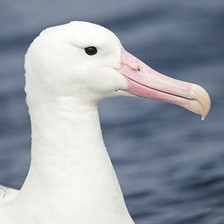

In [7]:
# loading image with PIL library

img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)

# img = Image.open('sample_images/albatross.jpg')  # alternative source

print(img.size)

img

In [8]:
# converting PIL image to torch.Tensor - detailed process

img_torch = torch.tensor(np.array(img), device=device)  # convert PIL image to np.array, then to torch.Tensor,

img_torch = img_torch.permute(2,0,1)  # reorder channels to move color to the front position, to match pytorch conventions

img_torch = img_torch / img_torch.max()  # scale to 0..1



img_torch.shape, img_torch.device, img_torch.min().item(), img_torch.max().item()  # verify shape, device and range

(torch.Size([3, 224, 224]),
 device(type='cuda', index=0),
 0.007843137718737125,
 1.0)

In [9]:
# converting PIL image to torch.Tensor - easy process

# PIL image to torch.Tensor can be converted with torchvision.transforms, equivalent to the above code (more details below)

img_torch = transforms.ToTensor()(img)

img_torch.shape, img_torch.max(), img_torch.min()

(torch.Size([3, 224, 224]), tensor(1.), tensor(0.0078))

In [10]:
# Predicting image class with pretrained model





def predict_img(img, model, top_n=5):

    if isinstance(img, str):

        Image.open(requests.get(url, stream=True).raw).convert('RGB')  # for loading images from url



    img_torch = transforms.ToTensor()(img)  # to torch.Tensor, reorder color channels, s|cale to 0..1

    img_torch = transforms.Resize((224, 224))(img_torch)      # another useful transform to resize images

    img_torch = img_torch.unsqueeze(0)                        # add batch dimension (remember that model needs 4D input)

    img_torch = img_torch.to(device)                          # moving the tensor to device (presumably cuda, in initialized above)

    prediction = model(img_torch)                             # obtain prediction logits from the model

    probs = torch.nn.functional.softmax(prediction, dim=-1)   # convert logits into probabilities

    probs = probs.cpu().data.numpy()                          # convert CUDA tensor to numpy array



    top_ix = probs.ravel().argsort()[-1: -top_n - 1: -1]      # get indices of most probable classes

    print (f'top-{top_n} classes:')                           # look up class label

    for l in top_ix:

        print (f"{probs.ravel()[l]:>6.2%}  {imagenet_labels[l].split(',')[0]}")





predict_img(img, model)

top-5 classes:
98.70%  albatross
 0.46%  spoonbill
 0.39%  American_egret
 0.19%  goose
 0.12%  crane


### testing the pretrained model 3: Images from unknown classes



Play with imahes from these and other (yours) URLS. Note how object outsize of imagenet classes confuse the net. Low probabilities in top classes are indications of model's low confidence.

(1200, 790)


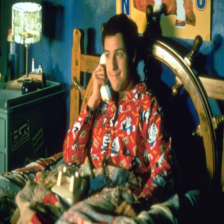

top-5 classes:
19.94%  pajama
 4.57%  hoopskirt
 4.11%  abaya
 4.11%  poncho
 3.75%  book_jacket


In [11]:
url= 'https://i.ebayimg.com/images/g/yDwAAOSwquxgTmcv/s-l1200.jpg'                    # modern version



# <TRY ANY OTHER IMAGES YOU LIKE>



web_img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

print(web_img.size)

display(transforms.Resize((224, 224))(web_img))

predict_img(web_img, model)

## More Torchvision tools: Transforms and transform pipelines¶



You already used `transforms.ToTensor` and `transforms.Resize` above. There are many more at [Torchvision](https://pytorch.org/vision/stable/transforms.html). For easier application they are typically combined into pipelines. See examples below.



For more advanced tranforms (faster and compatible with tasks requiring mask or reference points), check out [Albumentations library](https://albumentations.ai/).

In [12]:
from torchvision import transforms



# Typical transform pipeline for test loop

transform_pipeline = transforms.Compose([

    transforms.ToTensor(),

    transforms.Resize((224, 224)),

    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Optional: normalize imaged according to ImageNet standards

])



img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)

# img = Image.open('sample_images/albatross.jpg')  # alt link

img_torch = transform_pipeline(img)



print(type(img_torch), img_torch.shape)

<class 'torch.Tensor'> torch.Size([3, 224, 224])


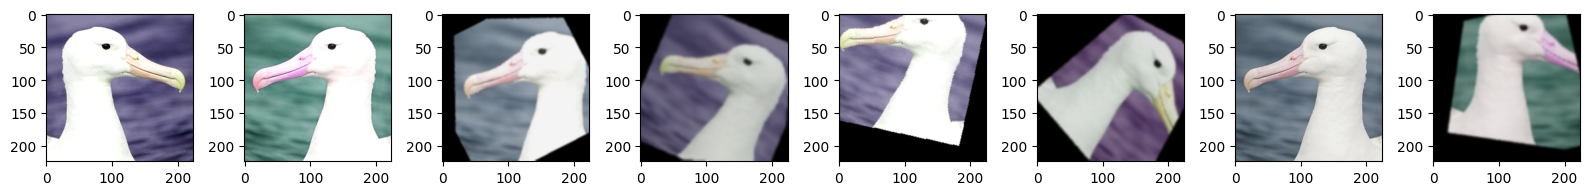

In [13]:
img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)

# img = Image.open('sample_images/albatross.jpg')  # alternative source



# Demo of augmentations for train pipeline



transform_pipeline_2 = transforms.Compose([

    transforms.RandomCrop((224, 224)),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),

    transforms.RandomApply([

        transforms.RandomAffine(degrees=30, translate=(0.2, 0.2)),

        transforms.RandomRotation(30),

        transforms.GaussianBlur(kernel_size=25),

    ], p=0.5),

    transforms.RandomHorizontalFlip(),

    # transforms.RandomVerticalFlip(),  # not always applicable

    transforms.ToTensor(),

    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Optional: normalizes imaged according to ImageNet standards

])



fig, axs = plt.subplots(1, 8, figsize=(16, 4))

for i, ax in enumerate(axs.ravel()):

    img_2 = transform_pipeline_2(img)

    ax.imshow(img_2.permute(1, 2, 0))

plt.tight_layout()

# Classifying with CNN model's latent features

Pretrained image classification models learn extract image features that are useful in classification tasks. We need to get those features from outputs of the model's penultimate level and pass them to classifier.

While this is not exactly a proper finetuning, this method is quick, rather robust and allows to classify unknown classes using quite small training sets (tens / hundreds of images).

### How to get features

features = activations before the very last Linear layer of the model (named `fc` in Resnet - check the model structure above.



During good old days in Torch7 you could access any intermediate output from the sequential model. Nowadays it's a bit more difficult though it's not Tensorflow where you need to compile another model for that. Here we're going to redefine the last layer... yes, to do nothing.

In [14]:
class Identity(torch.nn.Module):

    """replacement for the last model layer to deliver the unaltered inputs of the last layer"""



    def forward(self, x):

        return x



# it is practically same as torch.nn.Identity() - check https://pytorch.org/docs/stable/_modules/torch/nn/modules/linear.html#Identity

In [15]:
# Create model clone with altered last layer

embedding_model = deepcopy(model)  # start with a clone of the original model

embedding_model.fc = Identity()    # redefine the last layer to be Identity|

embedding_model = embedding_model.to(device)  # move the result to CUDA

In [16]:
img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)

# img = Image.open('sample_images/albatross.jpg') # alt link

img_torch = transforms.ToTensor()(img).unsqueeze(0).to(device)

out = embedding_model(img_torch).cpu().data.numpy()

assert out.shape == (1, 512), "your output for single image should have shape (1, 512)"

# Starter problem: cat-dog classification

Your next task is to use a pre-trained model to distinguish between cats and dogs.

- viewed as imposible in 2000

- popular data science challenge problem in 2010

- warm-up task for students in 2020s <br>

![cat_meme](https://i.imgur.com/u1bubWv.jpeg)

In [17]:
# download the dataset

!wget https://storage.yandexcloud.net/yandex-research/courses/dogs_vs_cats_1000.zip -O dogs_vs_cats_1000.zip

--2024-10-10 10:11:16--  https://storage.yandexcloud.net/yandex-research/courses/dogs_vs_cats_1000.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46394659 (44M) [application/zip]
Saving to: 'dogs_vs_cats_1000.zip'

dogs_vs_cats_1000.z 100%[===================>]  44.25M  14.2MB/s    in 3.9s    

2024-10-10 10:11:21 (11.2 MB/s) - 'dogs_vs_cats_1000.zip' saved [46394659/46394659]



In [18]:
!unzip -qn dogs_vs_cats_1000.zip

!ls dogs_vs_cats_1000 | wc -l  # should be 2000 images extracted

2000


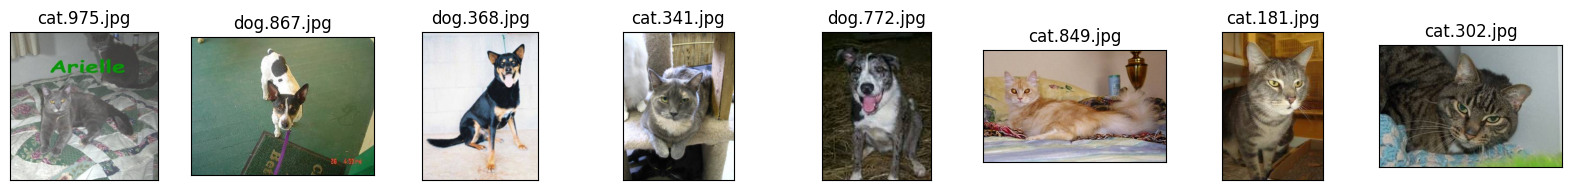

In [19]:
# Sample pets images

import random

fig, axs = plt.subplots(1, 8, figsize=(16, 2))



fnames = [fn for fn in os.listdir('dogs_vs_cats_1000')]

for ax, fname in zip(axs.ravel(), random.choices(fnames, k=8)):

    img_ = Image.open(os.path.join('dogs_vs_cats_1000', fname))

    ax.imshow(img_)

    ax.set_title(f"{fname}")

    ax.tick_params(left = False,labelleft = False , labelbottom = False, bottom = False)

plt.tight_layout()

In [20]:
# Here we generate image embeddings using the activations before the last layer

# use batches to accelerate the process



X_ = []  # storage for batches embeddings

Y_ = []  # storage for batches labels



filenames = [fname for fname in os.listdir('dogs_vs_cats_1000')]

batch_size = 64

x_batch_list = []  # to accumulate batch components



with torch.no_grad():

    for i, fname in enumerate(tqdm(filenames)):

        img = Image.open(os.path.join("dogs_vs_cats_1000", fname))

        img_torch = transforms.ToTensor()(img.resize((224, 224)))

        x_batch_list.append(img_torch)

        Y_.append(1 if fname.startswith("cat") else 0)



        if len(x_batch_list) == batch_size or i >= len(filenames) - 1:

            x_batch = torch.stack(x_batch_list)

            # use your embedding model to produce embeddings vectors, convert result to numpy array

            embeddings = embedding_model(x_batch.to(device)).cpu()



            assert isinstance(embeddings,  torch.Tensor)

            assert embeddings.ndim == 2 and embeddings.shape[1] == 512

            X_.append(embeddings)

            x_batch_list = []

  0%|          | 0/2000 [00:00<?, ?it/s]

In [21]:
X = np.concatenate(X_, axis = 0)  # concatenate all batches' embeddings into single 2D array.

Y = np.array(Y_[:len(X)])  # convert labels into np array; crop if we ended prematurely



print(X.shape, Y.shape, np.mean(Y))



assert X.ndim == 2 and X.shape[1] == 512

assert X.shape[0] == len(filenames)

assert Y.ndim == 1 and Y.shape[0] == X.shape[0]

assert 0.49 <= np.mean(Y) <= 0.51

(2000, 512) (2000,) 0.5


### embeddings classification with ML-1 tools

In [22]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

* Train sklearn model, evaluate validation accuracy (should be >90%)

__Task 1 (2 points)__:<br>  

- write the code for cats/dogs classification using the embeddings created above. Use any classification tools that you learned. Reach at least 95% accuracy. __(1 point)__.  Try few different tools if accuracy is not high enough. <br>

(You may choose any classifier algorithm as long as it gets above 95% accuracy. To get the max grade here, you need to tune main hyperparameters of your chosen algorithm (e.g. k for KNN, tree depth, logreg C) depending on how many data points you have. )

- try this excercise with much smaller training set. Find the lowest train set size that you can at which you can still predict cat/dog class with 95% accuracy __(1 point)__ <br>

(note: exact threshold may depend on algorightm choice and train/test split. Show your effort in  experimenting with low train set sizes.)

In [23]:
%%time

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=100)



beast_acc = 0

best_n_neighbors = 0

n_neighbors_cands = list(range(1, 25))

for n_neighbors in n_neighbors_cands:

    mean_acc = 0

    for state in range(100):

        _X_train, _X_val, _Y_train, _Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=state)



        knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)

        knn_model.fit(_X_train, _Y_train)



        Y_pred = knn_model.predict(_X_val)

        acc = (Y_pred == _Y_val).sum() / Y_pred.shape[0]

        mean_acc += acc / 100



    if beast_acc < mean_acc:

        beast_acc = mean_acc

        best_n_neighbors = n_neighbors





knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)

knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)



print(f"best n_neighbours: {best_n_neighbors}")

print(f"accuracy = {(Y_pred == Y_test).sum() / Y_pred.shape[0]:.1%}")

best n_neighbours: 22
accuracy = 93.5%
CPU times: user 1min 34s, sys: 1.71 s, total: 1min 36s
Wall time: 48 s


In [24]:
%%time

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=50)



thresholds = np.arange(0.02, 0.25, 0.01)

for thr in thresholds:

    beast_acc = 0

    best_n_neighbors = 0

    n_neighbors_cands = list(range(1, 25))



    _, X_train_small, _, Y_train_small = train_test_split(X_train, Y_train, test_size=thr, random_state=99)

    for n_neighbors in n_neighbors_cands:

        mean_acc = 0

        for state in range(100):

            _X_train, _X_val, _Y_train, _Y_val = train_test_split(X_train_small, Y_train_small, test_size=0.1, random_state=state)



            knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)

            knn_model.fit(_X_train, _Y_train)



            Y_pred = knn_model.predict(_X_val)

            acc = (Y_pred == _Y_val).sum() / Y_pred.shape[0]

            mean_acc += acc / 100



        if beast_acc < mean_acc:

            beast_acc = mean_acc

            best_n_neighbors = n_neighbors





    knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)

    knn_model.fit(X_train_small, Y_train_small)

    Y_pred = knn_model.predict(X_test)



    print(f"accuracy for {int(thr * len(X_train))} train samples = {(Y_pred == Y_test).sum() / Y_pred.shape[0]:.1%}")

accuracy for 36 train samples = 92.5%
accuracy for 54 train samples = 95.5%
accuracy for 71 train samples = 96.0%
accuracy for 89 train samples = 95.0%
accuracy for 108 train samples = 95.0%
accuracy for 125 train samples = 96.0%
accuracy for 143 train samples = 94.5%
accuracy for 162 train samples = 95.0%
accuracy for 179 train samples = 96.0%
accuracy for 197 train samples = 96.0%
accuracy for 215 train samples = 96.5%
accuracy for 233 train samples = 96.0%
accuracy for 251 train samples = 97.0%
accuracy for 269 train samples = 97.0%
accuracy for 287 train samples = 97.5%
accuracy for 305 train samples = 98.0%
accuracy for 323 train samples = 97.5%
accuracy for 341 train samples = 97.0%
accuracy for 359 train samples = 95.0%
accuracy for 377 train samples = 96.5%
accuracy for 395 train samples = 96.5%
accuracy for 413 train samples = 96.0%
accuracy for 431 train samples = 96.5%
CPU times: user 7min 59s, sys: 12 s, total: 8min 11s
Wall time: 4min 5s


The minimum required number of samples in the train set to achieve 95% accuracy is at least 108 samples using the split above.

## Torchvision Datasets

- Built-in datasets https://pytorch.org/vision/stable/datasets.html#built-in-datasets



- Datasets and Dataloaders at `torch.utils.data`: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html



- Torchvision classes for custom datasets  https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets

# Problem 2: Clasification of cat/dog breeds using Oxford pets dataset



The next problem is to classify specific cat / dog breeds from popular Oxford pets dataset. It is conveniently provided by Pytorch so loading and using it is very easy.



Dataset home page: https://www.robots.ox.ac.uk/~vgg/data/pets/



Available from Pytorch: https://pytorch.org/vision/stable/generated/torchvision.datasets.OxfordIIITPet.html#torchvision.datasets.OxfordIIITPet




In [25]:
# Loading train and test subsets of the dataset

# using simple transform for both slices



train_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Resize((224, 224), antialias=True),

    transforms.RandomHorizontalFlip(),

    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),

])



test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Resize((224, 224), antialias=True),

    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

])



train_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', target_types='category', download=True, transform=train_transform)

test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', target_types='category', download=True, transform=test_transform)



print("dataset sizes:", len(train_dataset), len(test_dataset))



print(train_dataset.classes)

100%|██████████| 791918971/791918971 [00:27<00:00, 28383509.15it/s]


Extracting oxford-iiit-pet/images.tar.gz to oxford-iiit-pet


100%|██████████| 19173078/19173078 [00:01<00:00, 11453687.98it/s]


Extracting oxford-iiit-pet/annotations.tar.gz to oxford-iiit-pet
dataset sizes: 3680 3669
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [26]:
# create dataloaders to repack the datasets' data into batches

# read more



batch_size = 32

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("dataloader sizes:", len(train_dataloader), len(test_dataloader))

dataloader sizes: 115 115


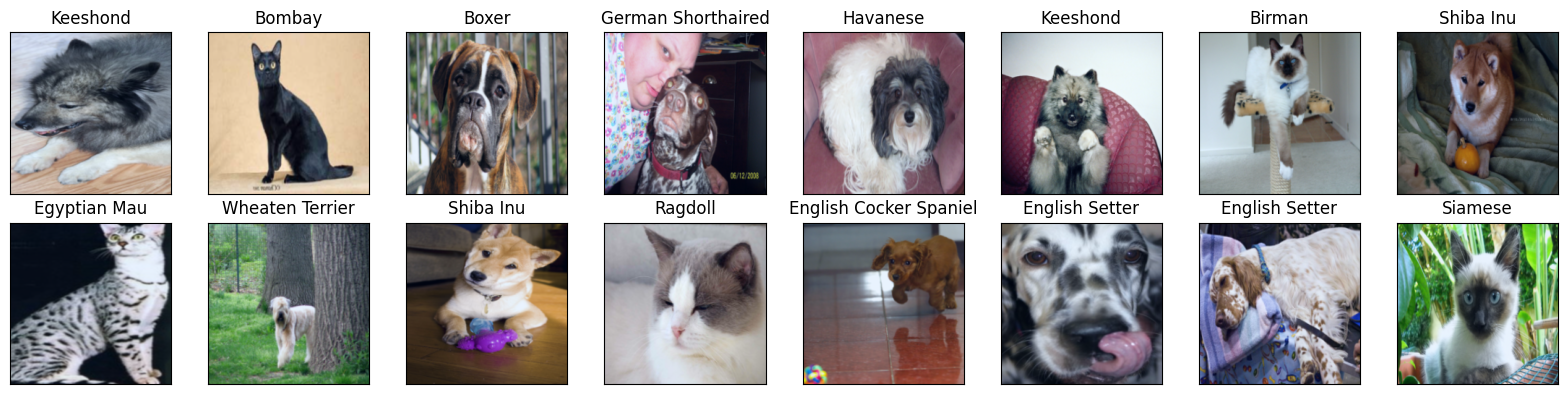

In [27]:
# Showing sample pets images

for x_batch, y_batch in train_dataloader:

    break  # Only get data from the 1st batch for now



fig, axs = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axs.ravel()):

    img_ = x_batch[i].permute(1, 2, 0) # restoring dimensions order

    img_ -= img_.min().item()  # normalizing image to 0..1

    img_ /= img_.max().item()

    ax.imshow(img_)

    label = train_dataset.classes[y_batch[i]]

    ax.set_title(f"{label}")

    ax.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)

plt.tight_layout()

Remember that Imagenet includes quite a few cat and dog breeds among its classes.



Let's try to predcit breeds with Imagenet-pretrained model without finetuning first

In [28]:
# Predicting breeds with Imagenet-pretrained model

Y_probs, Y_true = [], []

for x_batch, y_batch in tqdm(test_dataloader):

    with torch.no_grad():

        prediction = model(x_batch.to(device))

        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()

        Y_true.append(y_batch)

        Y_probs.append(probs)



Y_probs = torch.cat(Y_probs, axis=0)  # tensor with class probabilities

Y_true = torch.cat(Y_true)

Y_true.shape, Y_probs.shape

  0%|          | 0/115 [00:00<?, ?it/s]

(torch.Size([3669]), torch.Size([3669, 1000]))

In [29]:
# Output top 3 predictions for each class using pretrained CNN (no finetuning)

# Expect to see high accuracy (70-80%) in some classes, much lower overal, mismatch in label spaces.



results_list = {}



for i, cl in enumerate(test_dataset.classes):

    class_stats = {"true_label":cl}

    probs1 = Y_probs[np.where(Y_true == i)].mean(axis=0).numpy()

    top_ix = probs1.argsort()[-1:][::-1]

    class_stats

    for j, l in enumerate(top_ix):

        class_stats = {f"pred_1": imagenet_labels[l],

                    f"prob_{1}": probs1.ravel()[l]}

    results_list[cl] = class_stats



df = pd.DataFrame(results_list).T.sort_values('prob_1', ascending=False)

float_cols = ['prob_1']

df.style.format('{:.2%}', subset=float_cols)

,pred_1,prob_1
Siamese,Siamese_cat,94.51%
Keeshond,keeshond,94.35%
Saint Bernard,Saint_Bernard,90.23%
Persian,Persian_cat,87.12%
Pomeranian,Pomeranian,85.34%
Pug,pug,84.19%
Samoyed,Samoyed,82.18%
Boxer,boxer,82.16%
Egyptian Mau,Egyptian_cat,82.02%
Leonberger,Leonberg,82.00%


### Finetuning CNN: classification layer only:



__Task 2: (3 points)__:<br>

Complete the code below and reach at least 85% accuracy by training only the classification layer:

In [30]:
ft_model = deepcopy(model)

for param in ft_model.parameters():
    param.requires_grad = False

ft_model.fc = torch.nn.Linear(512, 37)
ft_model.to(device)
# your task:
# 1) freeze all model parameters
# 2) replace model.fc with a new linear layer that has the appropriate number of outputs

assert all(not p.requires_grad for p in ft_model.parameters() if p not in set(ft_model.fc.parameters()))
assert ft_model.fc.out_features == len(train_dataset.classes)
assert ft_model.fc.weight.device == device, f"ft_model.fc must be on {device}"
assert ft_model.fc.weight.requires_grad

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.001)

In [31]:
# train the finetuning model in a standard training loop.



num_epochs = 100  # Adjust number of epochs if needed

i = 0



history = defaultdict(list)

for epoch in range(num_epochs):

    start_time = time.time()



    ft_model.train()

    train_losses = []

    pbar = tqdm(train_dataloader, leave=False)

    for x_batch, y_batch in pbar:



        # calculate model predictions, calculate loss, make optimizer step

        y_pred = ft_model(x_batch.to(device))

        loss = criterion(y_pred, y_batch.to(device))

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()



        train_losses.append(loss.item())

        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"



    ft_model.eval()

    with torch.no_grad():

        val_losses = []

        val_cnt, val_correct = 0, 0

        pbar = tqdm(test_dataloader, leave=False)

        for x_batch, y_batch in pbar:



            # get model predictions, measure loss, collect data for accuracy calc

            y_pred = ft_model(x_batch.to(device))

            loss = criterion(y_pred, y_batch.to(device))



            val_losses.append(loss.item())

            val_cnt += y_batch.shape[0]

            val_correct += (y_batch.to(device) == torch.argmax(y_pred, dim=1)).sum().item()

            pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"



        train_loss = np.mean(train_losses)

        val_loss = np.mean(val_losses)

        accuracy = val_correct / val_cnt

        history['train_loss'].append(train_loss)

        history['val_loss'].append(val_loss)

        history['accuracy'].append(accuracy)

        print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")



        if epoch > 2 and history['accuracy'][-1] < max(history['accuracy']):

            i += 1

            if i >= 3:

                break

        else:

            i = 0

print(f"Best Accuracy = {max(history['accuracy']):.2%}")

  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 0: train_loss=1.92675  val_loss=0.96409  accuracy=77.51%  epoch_time=42.5s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 8: train_loss=0.24134  val_loss=0.44203  accuracy=86.54%  epoch_time=42.6s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 9: train_loss=0.23151  val_loss=0.46040  accuracy=85.58%  epoch_time=42.2s
Best Accuracy = 86.84%


In [32]:
# This part of finetuning alone should deliver at least 85% accuracy.

assert accuracy > 0.85

In [33]:
# Predicting breeds with finetuned model



Y_probs, Y_true = [], []

for x_batch, y_batch in tqdm(test_dataloader):

    with torch.no_grad():

        prediction = ft_model(x_batch.to(device))

        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()

        Y_true.append(y_batch)

        Y_probs.append(probs)



Y_probs = torch.cat(Y_probs, axis=0)

Y_true = torch.cat(Y_true)

Y_true.shape, Y_probs.shape

  0%|          | 0/115 [00:00<?, ?it/s]

(torch.Size([3669]), torch.Size([3669, 37]))

In [34]:
# Measure Top1 prediction accuracy for each class



results_list = {}

total, correct = 0, 0



for i, cl in enumerate(test_dataset.classes):

    class_preds = np.where(Y_true == i)

    probs1 = Y_probs[class_preds].mean(axis=0).numpy()

    acc1 = probs1[i]

    class_stats = {"true_label":cl, 'acc1': acc1}

    total += class_preds[0].shape[0]

    correct += class_preds[0].shape[0] * acc1

    results_list[cl] = acc1



df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)

df.style.format('{:.2%}', subset=['acc1'])

,acc1
Keeshond,98.59%
German Shorthaired,96.42%
Samoyed,96.04%
Japanese Chin,93.99%
Scottish Terrier,93.85%
Saint Bernard,91.31%
Leonberger,90.63%
Great Pyrenees,90.18%
Newfoundland,88.53%
Russian Blue,88.03%


### Finetuning CNN: now unfreeze and train all layers:



__task 3 (5 points)__: Based on the previous task, continue finetuning the model run by training all of its layers. Obtain at least 90% accuracy (macro average, as defined in the code).

To reach 90%, you will need to experiment with network and/or training code, start from using improvements from the list below:



Scoring:

- reaching 90% accuracy - __3 points__

- testing out all 4 of these improvements - __2 points__:

    - Hyperparameters optimization

    - Image augmentation

    - Pretrained model selection

    - Early stopping training at epoch with best metric and / or loading the weights of best epoch. [read about `state_dict`](https://pytorch.org/tutorials/beginner/saving_loading_models.html#what-is-a-state-dict)

    

(you may not necessarily get spectacular results right away. Experiment and describe your actions and findings in a brief report in this notebook.)

- scoring above 90% -- __+1 BONUS point__ for every 1% improvement in accuracy above 90%



__Guidelines__: to improve quality of the finetuned model we can now train all of its layers.

- do this after initial training of classification layer

- set learning rate to much lower level to avoid explosion

- make all layers trainable using `requires_grad` param

In [35]:
from transformers import ViTForImageClassification

ft_model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224") # load model with best available weights
ft_model = ft_model.to(device)  # move the model to GPU if available
ft_model.train(False);        # set the model to evaluation mode

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [36]:
for param in ft_model.parameters():
    param.requires_grad = False

ft_model.classifier = torch.nn.Sequential(
    torch.nn.Linear(768, 768),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(768, 37),
)
ft_model.to(device)


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.001)

In [37]:
num_epochs = 100  # Adjust number of epochs if needed

i = 0



history = defaultdict(list)

for epoch in range(num_epochs):

    start_time = time.time()



    ft_model.train()

    train_losses = []

    pbar = tqdm(train_dataloader, leave=False)

    for x_batch, y_batch in pbar:
        # calculate model predictions, calculate loss, make optimizer step

        y_pred = ft_model(x_batch.to(device)).logits

        loss = criterion(y_pred, y_batch.to(device))

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()



        train_losses.append(loss.item())

        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"



    ft_model.eval()

    with torch.no_grad():

        val_losses = []

        val_cnt, val_correct = 0, 0

        pbar = tqdm(test_dataloader, leave=False)

        for x_batch, y_batch in pbar:



            # get model predictions, measure loss, collect data for accuracy calc

            y_pred = ft_model(x_batch.to(device)).logits

            loss = criterion(y_pred, y_batch.to(device))



            val_losses.append(loss.item())

            val_cnt += y_batch.shape[0]

            val_correct += (y_batch.to(device) == torch.argmax(y_pred, dim=1)).sum().item()

            pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"



        train_loss = np.mean(train_losses)

        val_loss = np.mean(val_losses)

        accuracy = val_correct / val_cnt

        history['train_loss'].append(train_loss)

        history['val_loss'].append(val_loss)
        history['accuracy'].append(accuracy)
        print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")



        if epoch > 2 and history['accuracy'][-1] < max(history['accuracy']):
            i += 1
            if i >= 3:
                break
        else:
            i = 0

print(f"Best Accuracy = {max(history['accuracy']):.2%}")

  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 0: train_loss=0.75667  val_loss=0.35180  accuracy=88.31%  epoch_time=80.1s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 7: train_loss=0.10848  val_loss=0.42619  accuracy=89.21%  epoch_time=80.7s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 8: train_loss=0.09462  val_loss=0.44992  accuracy=88.55%  epoch_time=81.0s
Best Accuracy = 89.29%


In [38]:
# Continue training with all layers involved

for param in ft_model.parameters():
    param.requires_grad = True

assert all (p.requires_grad for p in ft_model.parameters())

In [39]:
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.000001)  # reduce LR to avoid explosion



num_epochs = 100  # Adjust number of epochs if needed

i = 0



history = defaultdict(list)

for epoch in range(num_epochs):

    start_time = time.time()



    ft_model.train()

    train_losses = []

    pbar = tqdm(train_dataloader, leave=False)

    for x_batch, y_batch in pbar:



        # calculate model predictions, calculate loss, make optimizer step

        y_pred = ft_model(x_batch.to(device)).logits

        loss = criterion(y_pred, y_batch.to(device))

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()



        train_losses.append(loss.item())

        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"



    ft_model.eval()

    with torch.no_grad():

        val_losses = []

        val_cnt, val_correct = 0, 0

        pbar = tqdm(test_dataloader, leave=False)

        for x_batch, y_batch in pbar:



            # get model predictions, measure loss, collect data for accuracy calc

            y_pred = ft_model(x_batch.to(device)).logits

            loss = criterion(y_pred, y_batch.to(device))



            val_losses.append(loss.item())

            val_cnt += y_batch.shape[0]

            val_correct += (y_batch.to(device) == torch.argmax(y_pred, dim=1)).sum().item()

            pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"



        train_loss = np.mean(train_losses)

        val_loss = np.mean(val_losses)

        accuracy = val_correct / val_cnt

        history['train_loss'].append(train_loss)

        history['val_loss'].append(val_loss)

        history['accuracy'].append(accuracy)

        print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")



        if epoch > 2 and history['accuracy'][-1] < max(history['accuracy']):

            i += 1

            if i >= 3:

                break

        else:

            i = 0

print(f"Best Accuracy = {max(history['accuracy']):.2%}")

  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep. 0: train_loss=0.08361  val_loss=0.39570  accuracy=89.89%  epoch_time=125.2s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/115 [00:00<?, ?it/s]

Ep.15: train_loss=0.02050  val_loss=0.35536  accuracy=91.09%  epoch_time=124.9s


  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

Ep.16: train_loss=0.01950  val_loss=0.35433  accuracy=91.01%  epoch_time=124.9s
Best Accuracy = 91.20%


In [40]:
# Predicting breeds with finetuned model



Y_probs, Y_true = [], []

for x_batch, y_batch in tqdm(test_dataloader):

    with torch.no_grad():

        prediction = ft_model(x_batch.to(device)).logits

        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()

        Y_true.append(y_batch)

        Y_probs.append(probs)



Y_probs = torch.cat(Y_probs, axis=0)

Y_true = torch.cat(Y_true)



# Measure Top1 prediction accuracy for each class



results_list = {}

total, correct = 0, 0



for i, cl in enumerate(test_dataset.classes):

    class_preds = np.where(Y_true == i)

    probs1 = Y_probs[class_preds].mean(axis=0).numpy()

    acc1 = probs1[i]

    class_stats = {"true_label":cl, 'acc1': acc1}

    total += class_preds[0].shape[0]

    correct += class_preds[0].shape[0] * acc1

    results_list[cl] = acc1



df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)

df.style.format('{:.2%}', subset=['acc1'])

  0%|          | 0/115 [00:00<?, ?it/s]

,acc1
German Shorthaired,99.85%
Keeshond,99.10%
Saint Bernard,97.75%
Newfoundland,97.22%
Leonberger,97.04%
Scottish Terrier,97.04%
Samoyed,97.01%
English Cocker Spaniel,96.78%
Sphynx,96.62%
Yorkshire Terrier,96.30%


In [41]:
print(f"Overall Accuracy = {correct / total:.2%}")  # macro-averaged accuracy

assert correct / total >= 0.9

Overall Accuracy = 90.01%


# STUDENT'S REPORT



Please write a short report describing the steps you took to improve quality. It should be at least a short paragraph with 3-5 sentences and, optionally, any relevant numbers/charts, but there's no upper limit.



Here's what i did:



0) Initially the accuracy was around 0.86-0.87 when I just fixed the code. The finetuning did not bring good improvements



1) First, I changed the early stopping strategy. Now it stops after n consecutive epochs with no validation score improvements



2) I tried the following data augmentations to the training data:

```transforms.RandomCrop((224, 224)),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),

    transforms.RandomApply([

        transforms.RandomAffine(degrees=30, translate=(0.2, 0.2)),

        transforms.RandomRotation(30),

        transforms.GaussianBlur(kernel_size=25),

    ], p=0.5),

    transforms.RandomHorizontalFlip()

```



3) I tried to replace the resnet18 to resnet34, however I run out of memory before finetuning after unfreezing the first layers.



4) I decreased the batch size to 32



5) I changed the transforms to

```

transforms.RandomCrop((224, 224)),

    transforms.RandomRotation(30),

    transforms.RandomAffine(degrees=30, translate=(0.2, 0.2)),

    transforms.RandomApply([

        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),

    ], p=0.1),

    transforms.RandomApply([

        transforms.GaussianBlur(kernel_size=25),

    ], p=0.1),

    transforms.RandomHorizontalFlip()

```

6) I reverted batch size to 64



7) I tried to run the last layer study with smaller learning rate on augmented data after the initial training. The quality was significantly lower, than before any changes



8) I removed all transforms, except for `transforms.RandomHorizontalFlip()` and reduced the learing rate of the training with all unfreezed layers.



9) I changed the transforms back and increased the learing rate of the training with all unfreezed layers.



10) I changed model to VIT , left only a horizontal flip and added random crop for augmentation. Also I replaced the final layer for nn.Sequintial with two layers.

# Bonus task __(optional. 2 more points)__:



Notice that accuracy varies across breeds. Build confusion Propose improvements to the model finetuning process to improve minimal accuracy levels for all classes. Show the model runs.

Measure the improvement in terms of minimal accuracy and micro-averaged accuracy.

# EXTRA STUFF:





## Links:    

- [The Building Blocks of Interpretability](https://distill.pub/2018/building-blocks/)

- [Activations Atlas](https://distill.pub/2019/activation-atlas/)

- more models from https://github.com/huggingface/pytorch-image-models

- Papers with code: benchmarks and model references. https://paperswithcode.com/sota/image-classification-on-imagenet